In [1]:
import os
import gc
import json
import time
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay, fbeta_score,
                             balanced_accuracy_score, f1_score, precision_recall_fscore_support)

import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import Adam 
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else 
                     ("mps" if torch.backends.mps.is_available() else "cpu"))

def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [3]:
print(f"Using device: {device}")

Using device: mps


In [4]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [5]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [6]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [7]:
# define transforms
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
CLASSES = sorted(train["class"].unique().tolist())  

toxic_class_name = 'toxic'
if toxic_class_name in CLASSES:
    toxic_idx = CLASSES.index(toxic_class_name)
else:
    print(f"Warning: '{toxic_class_name}' not found. Using class 0 as toxic.")
    toxic_idx = 0

In [10]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x3a037ba50>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x39d17ed90>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x39d17f2d0>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x3a038d890>}

In [11]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [12]:
criterion = nn.CrossEntropyLoss()

## Training and Validation

### Load RESNET50 Model

In [13]:
clear_memory()

In [14]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [15]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_best.pth"
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

In [16]:
def run_one_epoch(model, loader, criterion, optimizer, device, is_train=False, return_preds=False):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    model.train() if is_train else model.eval()
    num_batches = len(loader)
    
    for i, (img, labels) in enumerate(loader):
        img, labels = img.to(device), labels.to(device)

        with torch.set_grad_enabled(is_train):
            outputs = model(img)
            loss = criterion(outputs, labels)
            
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        preds = outputs.argmax(1)
        running_loss += loss.item() * img.size(0)
        running_correct += (preds == labels).sum().item()
        total += img.size(0)

        if (i + 1) % 5 == 0 or (i + 1) == num_batches:
            print(f"  {'Train' if is_train else 'Val'} [{i+1}/{num_batches}] Loss: {loss.item():.4f}", end='\r')

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    print() 
    avg_loss = running_loss / total
    avg_acc = running_correct / total

    if return_preds:
        y_true = torch.cat(all_labels).numpy()
        y_pred = torch.cat(all_preds).numpy()
        
        # Overall metrics
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        f1_m = f1_score(y_true, y_pred, average='macro')
        f1_w = f1_score(y_true, y_pred, average='weighted')
        
        # Toxic class metrics (precision, recall, F1) – no F2
        prec, rec, f1_tox, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[toxic_idx], beta=1.0, zero_division=0
        )
        
        # Return 8 metrics: loss, acc, bal_acc, f1_m, f1_w, prec_tox, rec_tox, f1_tox
        metrics = (avg_loss, avg_acc, bal_acc, f1_m, f1_w, prec[0], rec[0], f1_tox[0])
        return metrics, y_true, y_pred
    
    # When not returning predictions, pad with None to keep tuple length consistent
    return (avg_loss, avg_acc, None, None, None, None, None, None), None, None

In [17]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5):
    best_val_acc = -float("inf")      # now tracking accuracy
    bad_epochs = 0

    for epoch in range(num_epochs):
        # Training
        t_metrics, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True
        )
        t_loss, t_acc = t_metrics[0], t_metrics[1]
        
        # Validation 
        v_metrics, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False, return_preds=True
        )
        # Unpack 8 metrics
        v_loss, v_acc, v_bal, v_f1_m, v_f1_w, v_tox_p, v_tox_r, v_tox_f1 = v_metrics

        current_lr = optimizer.param_groups[-1]['lr']

        print(f"\n{'='*20} EPOCH {epoch+1} {'='*20}")
        print(f"TRAIN: Loss {t_loss:.4f} | Acc {t_acc:.4f}")
        print(f"VAL:   Loss {v_loss:.4f} | Acc {v_acc:.4f} | Balanced: {v_bal:.4f}")
        # Show precision, recall, F1 for toxic class
        print(f"TOXIC: Precision: {v_tox_p:.4f} | Recall: {v_tox_r:.4f} | F1: {v_tox_f1:.4f}")
        print(f"LR:    {current_lr:.8f}")

        # Early stopping based on validation accuracy
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(">>> New Best Model Saved (by accuracy)!")
        else:
            bad_epochs += 1
            print(f"No accuracy improvement. Patience: {bad_epochs}/{patience}")
            if bad_epochs >= patience:
                print(f"!!! Early stopping triggered.")
                break
        
        clear_memory()

    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [18]:
model = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device=device, patience=5)

  Train [151/151] Loss: 0.4274
  Val [19/19] Loss: 0.3660

==================== EPOCH 1 ====================
TRAIN: Loss 0.5431 | Acc 0.7706
VAL:   Loss 0.3822 | Acc 0.8462 | Balanced: 0.8462
TOXIC: Precision: 0.8672 | Recall: 0.8823 | F1: 0.8747
LR:    0.00030000
>>> New Best Model Saved (by accuracy)!
  Train [151/151] Loss: 0.3428
  Val [19/19] Loss: 0.3322

==================== EPOCH 2 ====================
TRAIN: Loss 0.3860 | Acc 0.8421
VAL:   Loss 0.3267 | Acc 0.8726 | Balanced: 0.8726
TOXIC: Precision: 0.8776 | Recall: 0.9197 | F1: 0.8981
LR:    0.00030000
>>> New Best Model Saved (by accuracy)!
  Train [151/151] Loss: 0.2796
  Val [19/19] Loss: 0.3684

==================== EPOCH 3 ====================
TRAIN: Loss 0.3308 | Acc 0.8676
VAL:   Loss 0.3451 | Acc 0.8593 | Balanced: 0.8593
TOXIC: Precision: 0.8857 | Recall: 0.9116 | F1: 0.8984
LR:    0.00030000
No accuracy improvement. Patience: 1/5
  Train [151/151] Loss: 0.3529
  Val [19/19] Loss: 0.2875

==================== EPOCH 

In [19]:
print("FINAL EVALUATION ON TEST SET")
model.eval()
with torch.no_grad():
    t_metrics, y_true, y_pred = run_one_epoch(
        model, test_loader, criterion, None, device, is_train=False, return_preds=True
    )
    # unpack 
    t_loss, t_acc, t_bal, t_f1m, t_f1w, t_prec, t_rec, t_f1tox = t_metrics

print(f"Accuracy:  {t_acc:.4f} (Balanced: {t_bal:.4f})")
print(f"Toxic - Precision: {t_prec:.4f} | Recall: {t_rec:.4f} | F1: {t_f1tox:.4f}")
print("-" * 50)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

FINAL EVALUATION ON TEST SET
  Val [19/19] Loss: 0.3777
Accuracy:  0.8815 (Balanced: 0.8815)
Toxic - Precision: 0.8757 | Recall: 0.9215 | F1: 0.8981
--------------------------------------------------

Detailed Classification Report:
                      precision    recall  f1-score   support

conditionally_edible     0.8687    0.8903    0.8794      1605
              edible     0.9022    0.8325    0.8659      1606
               toxic     0.8757    0.9215    0.8981      1606

            accuracy                         0.8815      4817
           macro avg     0.8822    0.8815    0.8811      4817
        weighted avg     0.8822    0.8815    0.8811      4817



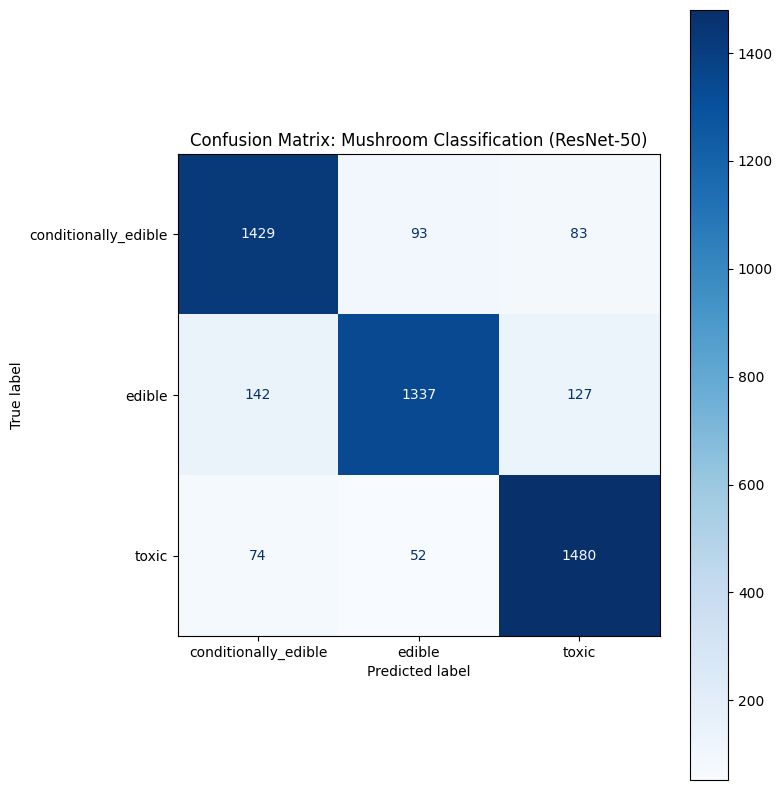

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Confusion Matrix: Mushroom Classification (ResNet-50)")
plt.tight_layout()
plt.savefig("resnet50_final_confusion_matrix.png", dpi=300)
plt.show()

torch.save(model.state_dict(), "Mushroom_ResNet50_Final.pth")

In [21]:
clear_memory()